# GD vs GA  -  Urban Sound Classification
**Custom Smart Adaptive Systems · UPC 2025/26**

We train the same small neural network in two fundamentally different ways and compare them:

| Method | Idea | Uses gradients? |
|--------|------|-----------------|
| **GD**  -  Adam optimizer | Follows the gradient downhill in loss space | Yes |
| **GA**  -  Genetic Algorithm (DEAP) | Evolves a population of weight vectors | No |

Run cells top to bottom. Figures are saved to `results/figures/`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from matplotlib.patches import Patch

import random, time, os

plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})

BLUE   = '#1565C0'   # GD  -  deep blue
ORANGE = '#F57C00'   # GA  -  orange
PINK   = '#C2185B'   # baseline / accent

GD   = BLUE
GA   = ORANGE
SAVE = dict(dpi=150, bbox_inches='tight')

os.makedirs('results/figures', exist_ok=True)

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [2]:
# Load best hyperparameters found by tuning.ipynb
# Falls back to well-chosen defaults when the JSON does not exist yet.
import json as _json, os as _os

_params_path = "results/best_params.json"
if _os.path.exists(_params_path):
    with open(_params_path) as _f:
        _p = _json.load(_f)
    GD_LR, GD_WD, GD_HIDDEN = _p["gd"]["lr"], _p["gd"]["weight_decay"], _p["gd"]["hidden_dim"]
    GA_POP, GA_CXPB, GA_MUTPB, GA_ELITE = (_p["ga"]["pop_size"], _p["ga"]["cxpb"],
                                             _p["ga"]["mutpb"],   _p["ga"]["elite_k"])
    print(f"Tuned params loaded from {_params_path}")
    print(f"  GD : lr={GD_LR:.2e}  wd={GD_WD:.2e}  hidden={GD_HIDDEN}")
    print(f"  GA : N={GA_POP}  cxpb={GA_CXPB:.2f}  mutpb={GA_MUTPB:.2f}  elite_k={GA_ELITE}")
else:
    GD_LR, GD_WD, GD_HIDDEN = 1e-3, 1e-4, 20
    GA_POP, GA_CXPB, GA_MUTPB, GA_ELITE = 100, 0.7, 0.05, 5
    print("results/best_params.json not found - using defaults")
    print(f"  GD : lr={GD_LR:.2e}  wd={GD_WD:.2e}  hidden={GD_HIDDEN}")
    print(f"  GA : N={GA_POP}  cxpb={GA_CXPB:.2f}  mutpb={GA_MUTPB:.2f}  elite_k={GA_ELITE}")


Tuned params loaded from results/best_params.json
  GD : lr=4.96e-03  wd=3.29e-05  hidden=60
  GA : N=100  cxpb=0.72  mutpb=0.05  elite_k=1


---
## 1 · Dataset

The **UrbanSound8K** dataset contains 8 674 short audio clips across 10 urban sound classes.
Instead of raw audio (which would require a CNN or spectrogram pipeline),
we use a tabular version where each clip is already summarised as **34 numbers**:

| Feature group | # | What it captures |
|---|---|---|
| MFCC | 13 | Spectral envelope  -  most important for sound identity |
| Chroma | 12 | Pitch-class energy  -  which musical notes are present |
| Spectral Contrast | 7 | Peak vs valley energy  -  texture of the sound |
| Zero Crossing Rate | 1 | How noisy vs tonal the sound is |
| Spectral Centroid | 1 | Brightness  -  where the energy is concentrated |

In [3]:
df = pd.read_csv('data/extracted_audio_features.csv')
print(f'{df.shape[0]} samples  ·  {df.shape[1]-1} features  ·  {df["class"].nunique()} classes')
df.head(3)

8674 samples  ·  34 features  ·  10 classes


,MFCC_1,MFCC_2,MFCC_3,MFCC_4,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10,...,SpectralContrast_1,SpectralContrast_2,SpectralContrast_3,SpectralContrast_4,SpectralContrast_5,SpectralContrast_6,SpectralContrast_7,ZeroCrossingRate,SpectralCentroid,class
0,-351.31754,117.981636,-95.81988,-65.534320,-41.541040,1.260002,-26.543507,-5.355432,9.728725,5.192412,...,16.091527,8.252967,18.333769,16.360728,18.070850,19.286706,21.688631,0.066302,2501.385833,dog_bark
1,-573.23320,183.838800,-86.40056,48.547085,9.983089,21.652693,-2.877878,11.374228,7.863986,-6.933499,...,9.900955,8.370619,12.350664,15.133860,17.163035,22.989626,27.065551,0.071667,2232.577799,children_playing
2,-604.57500,186.740570,-71.29498,40.730904,8.443645,18.890660,5.850036,15.935515,8.743742,-6.695419,...,9.635166,8.230098,11.714580,15.619163,16.035485,22.211784,24.615103,0.052590,1956.527004,children_playing


### Class distribution
Most classes have ~1 000 samples, but **car_horn** (~430) and **gun_shot** (~374) are underrepresented.
This matters: we use *stratified* splitting so these minority classes appear fairly in every split.

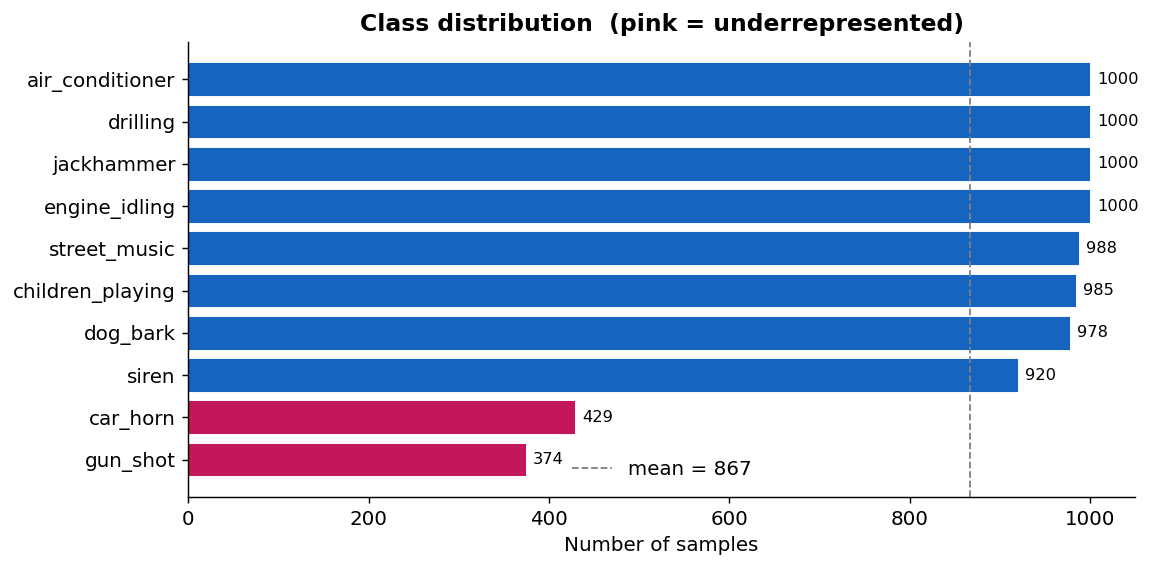

In [4]:
counts = df['class'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(counts.index, counts.values,
               color=[(PINK if v < 500 else BLUE) for v in counts.values],
               edgecolor='white', linewidth=0.5)
ax.set_xlabel('Number of samples')
ax.set_title('Class distribution  (pink = underrepresented)')
ax.axvline(counts.mean(), color='grey', linestyle='--', linewidth=1, label=f'mean = {counts.mean():.0f}')
ax.legend(frameon=False)
for bar, v in zip(bars, counts.values):
    ax.text(v + 8, bar.get_y() + bar.get_height()/2, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('results/figures/class_distribution.png', **SAVE)
plt.show()

### Feature importance (mutual information)
Mutual information measures how much knowing a feature reduces uncertainty about the class label.
Higher = more useful for classification. MFCC features dominate, which is expected  - 
they capture the spectral shape that makes each sound unique.

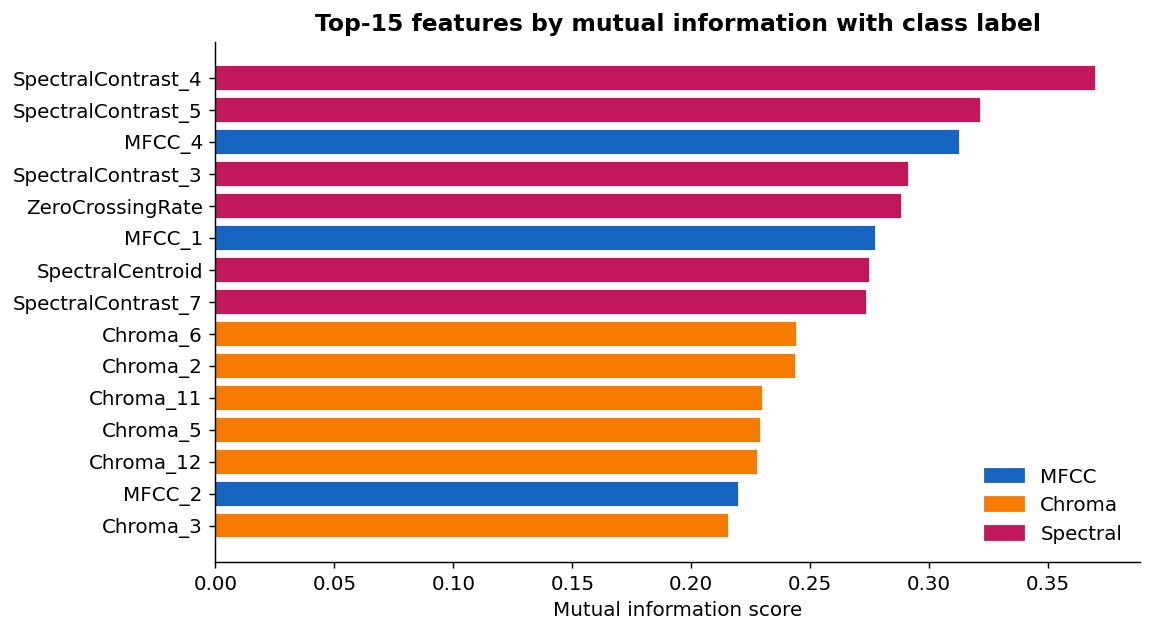

In [5]:
X_raw      = df.drop(columns=['class']).values.astype(np.float32)
le         = LabelEncoder()
y_raw      = le.fit_transform(df['class']).astype(np.int64)
feat_names = df.drop(columns=['class']).columns.tolist()
class_names = list(le.classes_)

mi    = mutual_info_classif(X_raw, y_raw, random_state=42)
mi_df = pd.Series(mi, index=feat_names).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 5))
colors = [BLUE if 'MFCC' in n else (ORANGE if 'Chroma' in n else PINK) for n in mi_df.index]
ax.barh(mi_df.index, mi_df.values, color=colors, edgecolor='white')
ax.set_xlabel('Mutual information score')
ax.set_title('Top-15 features by mutual information with class label')
ax.legend(handles=[
    Patch(color=BLUE,   label='MFCC'),
    Patch(color=ORANGE, label='Chroma'),
    Patch(color=PINK,   label='Spectral'),
], frameon=False)
plt.tight_layout()
plt.savefig('results/figures/feature_importance.png', **SAVE)
plt.show()

### PCA  -  are the classes linearly separable?
PCA projects 34 dimensions down to 2 by finding the directions of maximum variance.
If classes form distinct clusters here, a simple linear classifier would work well.
Overlap means the classification problem is genuinely hard  -  the MLP must learn non-linear boundaries.

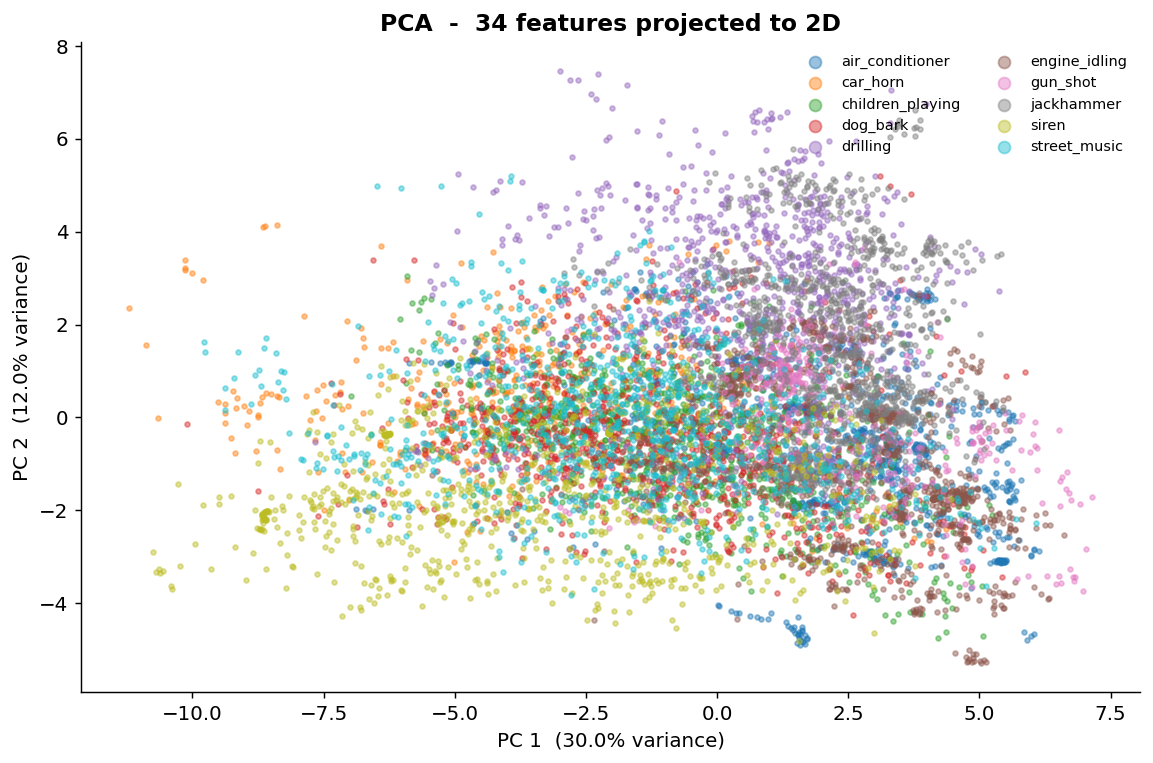

Total variance explained: 42.0%


In [6]:
X_scaled = StandardScaler().fit_transform(X_raw)
pca      = PCA(n_components=2, random_state=42)
X_pca    = pca.fit_transform(X_scaled)
palette  = plt.colormaps['tab10'].resampled(len(class_names))

fig, ax = plt.subplots(figsize=(9, 6))
for i, name in enumerate(class_names):
    mask = y_raw == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=7, alpha=0.45,
               color=palette(i), label=name, rasterized=True)
ax.set_xlabel(f'PC 1  ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC 2  ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA  -  34 features projected to 2D')
ax.legend(markerscale=2.5, fontsize=8, frameon=False, loc='upper right', ncol=2)
plt.tight_layout()
plt.savefig('results/figures/pca_2d.png', **SAVE)
plt.show()
print(f'Total variance explained: {sum(pca.explained_variance_ratio_)*100:.1f}%')

---
## 2 · Preprocessing

Three steps before any training:

1. **Stratified split**  -  70 % train · 10 % val · 20 % test.  
   Stratified = each class appears in all three sets at the same ratio as the full dataset.

2. **StandardScaler**  -  each feature is normalised to mean 0, std 1.  
   Fitted *only* on the training set, then applied to val and test.  
   If we fitted on all data we would leak information about the test set into the scaler.

3. **Tensors**  -  PyTorch needs its own tensor format for GPU-compatible operations.

In [7]:
X_tmp,   X_test,  y_tmp,   y_test  = train_test_split(X_raw,  y_raw,  test_size=0.2,   stratify=y_raw,  random_state=42)
X_train, X_val,   y_train, y_val   = train_test_split(X_tmp,  y_tmp,  test_size=0.125, stratify=y_tmp,  random_state=42)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

X_train_t, y_train_t = torch.tensor(X_train), torch.tensor(y_train)
X_val_t,   y_val_t   = torch.tensor(X_val),   torch.tensor(y_val)
X_test_t,  y_test_t  = torch.tensor(X_test),  torch.tensor(y_test)

print(f'Train {X_train.shape[0]}  ·  Val {X_val.shape[0]}  ·  Test {X_test.shape[0]}')

Train 6071  ·  Val 868  ·  Test 1735


---
## 3 · The MLP

```
Input (34)  ->  Linear(34->hidden_dim)  ->  ReLU  ->  Linear(hidden_dim->10)  ->  logits
```

**Architecture capacity**  
Too many parameters relative to training samples leads to overfitting; too few leads to underfitting.
A useful rule of thumb is at least 5 training samples per parameter.
The exact `hidden_dim` is selected by Optuna hyperparameter search (see `tuning.ipynb`);
loaded automatically from `results/best_params.json` in the `load0001` cell above.

**ReLU** -- activation between layers. Outputs 0 for negative inputs, x otherwise.
Allows the network to learn non-linear decision boundaries.

**CrossEntropyLoss** applies softmax internally, so `forward()` returns raw logits.

In [8]:
class MLP(nn.Module):
    def __init__(self, input_dim=34, hidden_dim=20, output_dim=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )
    def forward(self, x):
        return self.net(x)


def accuracy(model, X, y):
    model.eval()
    with torch.no_grad():
        return (model(X).argmax(dim=1) == y).float().mean().item()


# Tuned hidden_dim (from best_params.json)
n_params = sum(p.numel() for p in MLP(hidden_dim=GD_HIDDEN).parameters())
# Default hidden_dim=20, used by the baseline GA for a fair fixed-capacity comparison
n_params_orig = sum(p.numel() for p in MLP().parameters())
print(f'Parameters (hidden={GD_HIDDEN}): {n_params}   |   baseline (hidden=20): {n_params_orig}')

Parameters (hidden=60): 2710   |   baseline (hidden=20): 910


---
## 4 · Gradient Descent  -  Adam

**How it works, step by step:**

1. Take a mini-batch of 64 samples from the training set
2. Pass them through the network -> get 10 output scores per sample
3. Compute the **cross-entropy loss**  -  how wrong the predictions are
4. **Backpropagation**  -  compute the gradient of the loss w.r.t. every weight using the chain rule
5. **Adam** updates each weight by a small step in the direction that reduces the loss,
   with an adaptive per-weight step size based on the history of gradients
6. Repeat for all mini-batches -> that is one **epoch**

We run 150 epochs with a **cosine annealing schedule**: the learning rate starts at the tuned value
and decays smoothly to near-zero by epoch 150. This prevents late-training oscillations that occur
when the fixed LR is too large relative to the loss landscape near convergence.

In [9]:
EPOCHS, BATCH = 150, 64
LR, WD = GD_LR, GD_WD

gd_model  = MLP(hidden_dim=GD_HIDDEN)
optimizer = torch.optim.Adam(gd_model.parameters(), lr=LR, weight_decay=WD)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)
criterion = nn.CrossEntropyLoss()
loader    = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH, shuffle=True)

gd_loss, gd_train_acc, gd_val_acc = [], [], []

t0 = time.perf_counter()
for _ in range(EPOCHS):
    gd_model.train()
    epoch_loss = 0.0
    for xb, yb in loader:
        optimizer.zero_grad()
        loss = criterion(gd_model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    scheduler.step()
    gd_loss.append(epoch_loss / len(X_train_t))
    gd_train_acc.append(accuracy(gd_model, X_train_t, y_train_t))
    gd_val_acc.append(accuracy(gd_model, X_val_t, y_val_t))

gd_time     = time.perf_counter() - t0
gd_test_acc = accuracy(gd_model, X_test_t, y_test_t)
print(f'Test accuracy: {gd_test_acc:.4f}   Time: {gd_time:.1f}s')

Test accuracy: 0.8870   Time: 37.5s


### GD training curves
**Loss** should fall consistently  -  the network is getting better at fitting the training data.  
**Val accuracy** should track train accuracy closely. A large gap between the two signals overfitting.

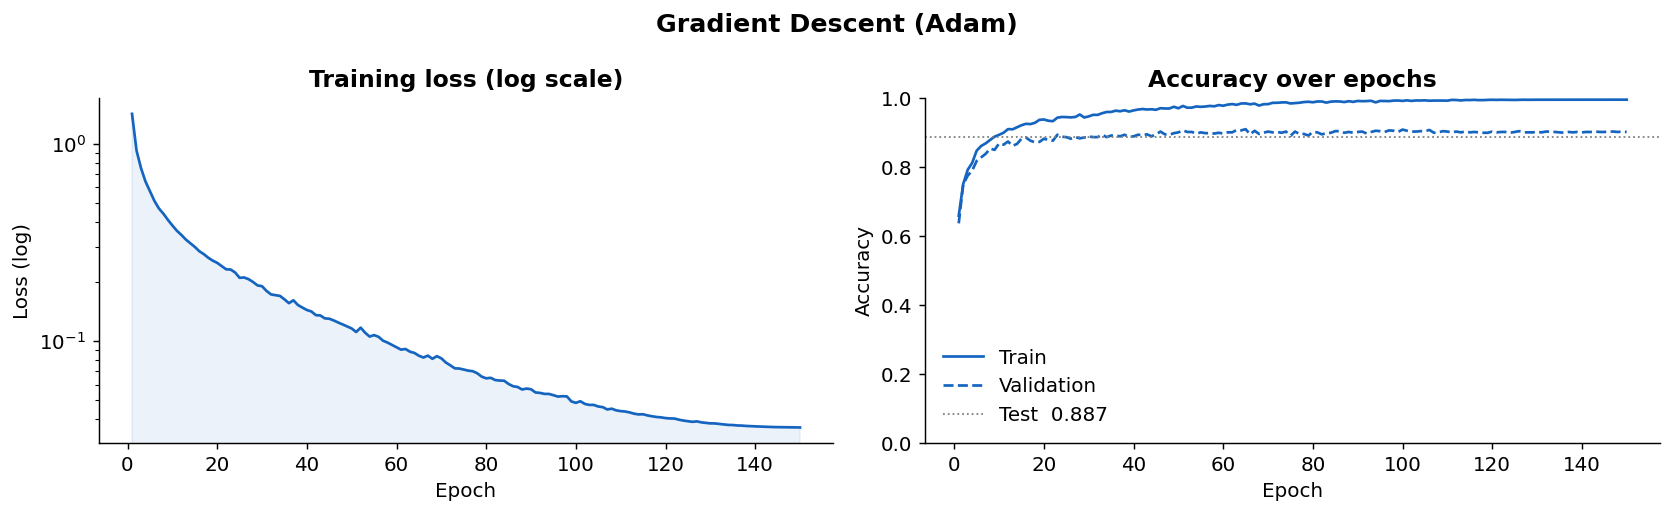

In [10]:
epochs = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs, gd_loss, color=GD, linewidth=1.5)
axes[0].fill_between(epochs, gd_loss, alpha=0.08, color=GD)
axes[0].set_yscale('log')
axes[0].set_title('Training loss (log scale)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (log)')

axes[1].plot(epochs, gd_train_acc, color=GD, linewidth=1.5, label='Train')
axes[1].plot(epochs, gd_val_acc,   color=GD, linewidth=1.5, label='Validation', linestyle='--')
axes[1].axhline(gd_test_acc, color='grey', linestyle=':', linewidth=1, label=f'Test  {gd_test_acc:.3f}')
axes[1].set_title('Accuracy over epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].legend(frameon=False)

plt.suptitle('Gradient Descent (Adam)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/gd_curves.png', **SAVE)
plt.show()

---
## 5 · Genetic Algorithm  --  DEAP

**The key idea:** instead of computing gradients, we maintain a population of candidate weight
vectors and evolve them over generations, inspired by natural selection.

**Chromosome** = one individual = a flat list of all MLP weights (n_params values).

**Each generation:**
1. **Evaluate**  --  load each individual's weights into the MLP, measure fitness (-loss)
2. **Select**  --  tournament: pick 5 individuals at random, keep the best. Repeat to fill offspring
3. **Crossover**  --  blend two parents' weights (BLX-alpha) to produce offspring
4. **Mutate**  --  add small Gaussian noise to a random subset of genes

`HallOfFame` tracks the single best individual ever seen across all generations.

**Why this is harder than GD:**
GD knows the direction to improve -- the gradient is a precise compass pointing downhill.
The GA only knows the final score, not which of the individual weights caused the error.
Searching an N-dimensional space this way is like finding the lowest point of a mountain range
blindfolded.

### 5a · Original GA  -  baseline
**Fitness = validation accuracy · No elitism · `eaSimple`**

In [11]:
from deap import algorithms as deap_algorithms, base, creator, tools
import torch.nn.utils as nn_utils

if not hasattr(creator, 'FitnessMax'):
    creator.create('FitnessMax', base.Fitness, weights=(1.0,))
if not hasattr(creator, 'Individual'):
    creator.create('Individual', list, fitness=creator.FitnessMax)

def set_weights(model, weights):
    nn_utils.vector_to_parameters(torch.tensor(weights, dtype=torch.float32), model.parameters())

ga_model_orig = MLP()   # fixed hidden=20 for baseline

def evaluate_orig(individual):
    set_weights(ga_model_orig, individual)
    return (accuracy(ga_model_orig, X_val_t, y_val_t),)

toolbox_orig = base.Toolbox()
toolbox_orig.register('attr_float',  random.gauss, 0.0, 0.1)
toolbox_orig.register('individual',  tools.initRepeat, creator.Individual, toolbox_orig.attr_float, n=n_params_orig)
toolbox_orig.register('population',  tools.initRepeat, list, toolbox_orig.individual)
toolbox_orig.register('evaluate',    evaluate_orig)
toolbox_orig.register('mate',        tools.cxBlend,       alpha=0.5)
toolbox_orig.register('mutate',      tools.mutGaussian,   mu=0.0, sigma=0.05, indpb=0.05)
toolbox_orig.register('select',      tools.selTournament, tournsize=5)

hof_orig   = tools.HallOfFame(1)
stats_orig = tools.Statistics(lambda ind: ind.fitness.values)
stats_orig.register('max', np.max)
stats_orig.register('avg', np.mean)
stats_orig.register('std', np.std)

t0 = time.perf_counter()
_, logbook_orig = deap_algorithms.eaSimple(
    toolbox_orig.population(n=100), toolbox_orig,
    cxpb=0.7, mutpb=0.3, ngen=150,
    stats=stats_orig, halloffame=hof_orig, verbose=False,
)
ga_time_orig = time.perf_counter() - t0
set_weights(ga_model_orig, hof_orig[0])
ga_test_acc_orig = accuracy(ga_model_orig, X_test_t, y_test_t)
ga_best_acc_orig = np.array(logbook_orig.select('max'))
print(f'Baseline GA  test accuracy: {ga_test_acc_orig:.4f}   time: {ga_time_orig:.1f}s')

Baseline GA  test accuracy: 0.3769   time: 20.5s


### 5b · Improved GA  --  -loss fitness + elitism

Two targeted improvements over the baseline:

**1. Fitness = -cross-entropy loss (instead of validation accuracy)**
Raw accuracy is a coarse, discontinuous signal -- two weight vectors that produce the same number
of correct predictions receive identical fitness scores even if their confidence levels differ.
Switching to negative cross-entropy gives a continuous, smooth signal: a confidently correct vector
scores better than a barely correct one, providing far more information for selection and crossover.

**2. Elitism  --  top-k individuals survive unchanged every generation**
Without elitism (`eaSimple`), the best individual found so far can be accidentally destroyed by
crossover or mutation. Elitism copies the top-k individuals unchanged into the next generation,
guaranteeing the best solution never regresses while the rest of the population continues to evolve.

### What we changed  -  and why

Two targeted improvements over the baseline GA:

**1. Fitness = -cross-entropy loss (instead of validation accuracy)**

The baseline used raw accuracy as fitness: each individual scores between 0 and 1 based on how many samples it classifies correctly. This is a **coarse, discontinuous** signal  -  two weight vectors that produce very different confidence levels but the same number of correct predictions receive *identical* fitness scores, so the GA cannot distinguish between them.

Switching to **negative cross-entropy loss** gives the GA a **continuous, smooth** signal. A weight vector that is *confidently correct* scores better than one that is *barely correct*, and one that is *confidently wrong* scores much worse than one that is *slightly wrong*. This richer landscape gives selection and crossover far more information to work with.

**2. Elitism  -  top-5 individuals survive unchanged every generation**

In `eaSimple`, every individual is a candidate for replacement through crossover and mutation. The best individual found so far can be accidentally destroyed. With elitism, the top-5 individuals are copied unchanged into the next generation, **guaranteeing the best solution never regresses**. The remaining 95 individuals are still evolved normally, preserving population diversity.

In [12]:
ga_model  = MLP(hidden_dim=GD_HIDDEN)
ga_crit   = nn.CrossEntropyLoss()

# Improvement 1: fitness = -loss (continuous signal, not coarse accuracy)
def evaluate(individual):
    set_weights(ga_model, individual)
    ga_model.eval()
    with torch.no_grad():
        loss = ga_crit(ga_model(X_val_t), y_val_t).item()
    return (-loss,)

POP_SIZE = GA_POP
NGEN     = 150
CXPB     = GA_CXPB
MUTPB    = GA_MUTPB
ELITE_K  = GA_ELITE   # Improvement 2: elitism  -  top-5 survive every generation unchanged

toolbox = base.Toolbox()
toolbox.register('attr_float', random.gauss, 0.0, 0.1)
toolbox.register('individual', tools.initRepeat, creator.Individual, toolbox.attr_float, n=n_params)
toolbox.register('population', tools.initRepeat, list, toolbox.individual)
toolbox.register('evaluate', evaluate)
toolbox.register('mate',     tools.cxBlend,       alpha=0.5)
toolbox.register('mutate',   tools.mutGaussian,   mu=0.0, sigma=0.05, indpb=0.05)
toolbox.register('select',   tools.selTournament, tournsize=5)

print(f'Population: {POP_SIZE}  ·  Elitism: top-{ELITE_K}  ·  Fitness: -loss')


Population: 100  ·  Elitism: top-1  ·  Fitness: -loss


#### Run 3  -  Early stopping (up to 5 000 generations)

Both the 150-gen and 1 000-gen runs stopped at an arbitrary wall. Here we let the algorithm run until it stops improving on its own: if the best validation accuracy does not increase by more than **0.0001** for **50 consecutive generations**, we stop. This gives the GA a fair budget to find its natural convergence point.

This is the run whose weights are used in the §6 comparison.


In [13]:
hof   = tools.HallOfFame(1)
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register('max', np.max)
stats.register('avg', np.mean)
stats.register('std', np.std)

pop = toolbox.population(n=POP_SIZE)
for ind, fit in zip(pop, map(toolbox.evaluate, pop)):
    ind.fitness.values = fit
hof.update(pop)

logbook        = tools.Logbook()
logbook.header = ['gen'] + stats.fields
logbook.record(gen=0, **stats.compile(pop))

ga_best_acc = []   # accuracy of best individual each generation

# --- DYNAMIC ENDING VARIABLES ---
patience = 50           # The window W (generations to wait for improvement)
best_val_acc = 0.0      # Maximum accuracy state
stagnant_gens = 0       # Counter for consecutive generations without improvement
min_delta = 0.0001      # Minimum required improvement (epsilon)

t0 = time.perf_counter()
for gen in range(1, 5000 + 1):
    offspring = toolbox.select(pop, POP_SIZE - ELITE_K)
    offspring = list(map(toolbox.clone, offspring))
    
    for c1, c2 in zip(offspring[::2], offspring[1::2]):
        if random.random() < CXPB:
            toolbox.mate(c1, c2)
            del c1.fitness.values, c2.fitness.values
            
    for mutant in offspring:
        if random.random() < MUTPB:
            toolbox.mutate(mutant)
            del mutant.fitness.values

    invalid = [ind for ind in offspring if not ind.fitness.valid]
    for ind, fit in zip(invalid, map(toolbox.evaluate, invalid)):
        ind.fitness.values = fit

    elite  = list(map(toolbox.clone, tools.selBest(pop, ELITE_K)))
    pop[:] = offspring + elite

    hof.update(pop)
    logbook.record(gen=gen, **stats.compile(pop))

    set_weights(ga_model, hof[0])
    current_val_acc = accuracy(ga_model, X_val_t, y_val_t)
    ga_best_acc.append(current_val_acc)

    # --- DYNAMIC ENDING LOGIC ---
    if current_val_acc > (best_val_acc + min_delta):
        best_val_acc = current_val_acc
        stagnant_gens = 0  # Reset counter if improvement exceeds min_delta
    else:
        stagnant_gens += 1 # Increment counter otherwise

    if stagnant_gens >= patience:
        print(f'Early stopping triggered at generation {gen}')
        break

ga_time     = time.perf_counter() - t0
ga_test_acc = accuracy(ga_model, X_test_t, y_test_t)
print(f'Test accuracy: {ga_test_acc:.4f}   Time: {ga_time:.1f}s')

Early stopping triggered at generation 483
Test accuracy: 0.6121   Time: 122.5s


### GA convergence
**Left**  --  validation loss of the improved GA: best individual (Hall of Fame) vs population average;
the +/-1 std band shows how much diversity remains in the population over generations.
**Right**  --  best individual's validation accuracy per generation, baseline vs improved.
Dotted lines mark each variant's final test accuracy.

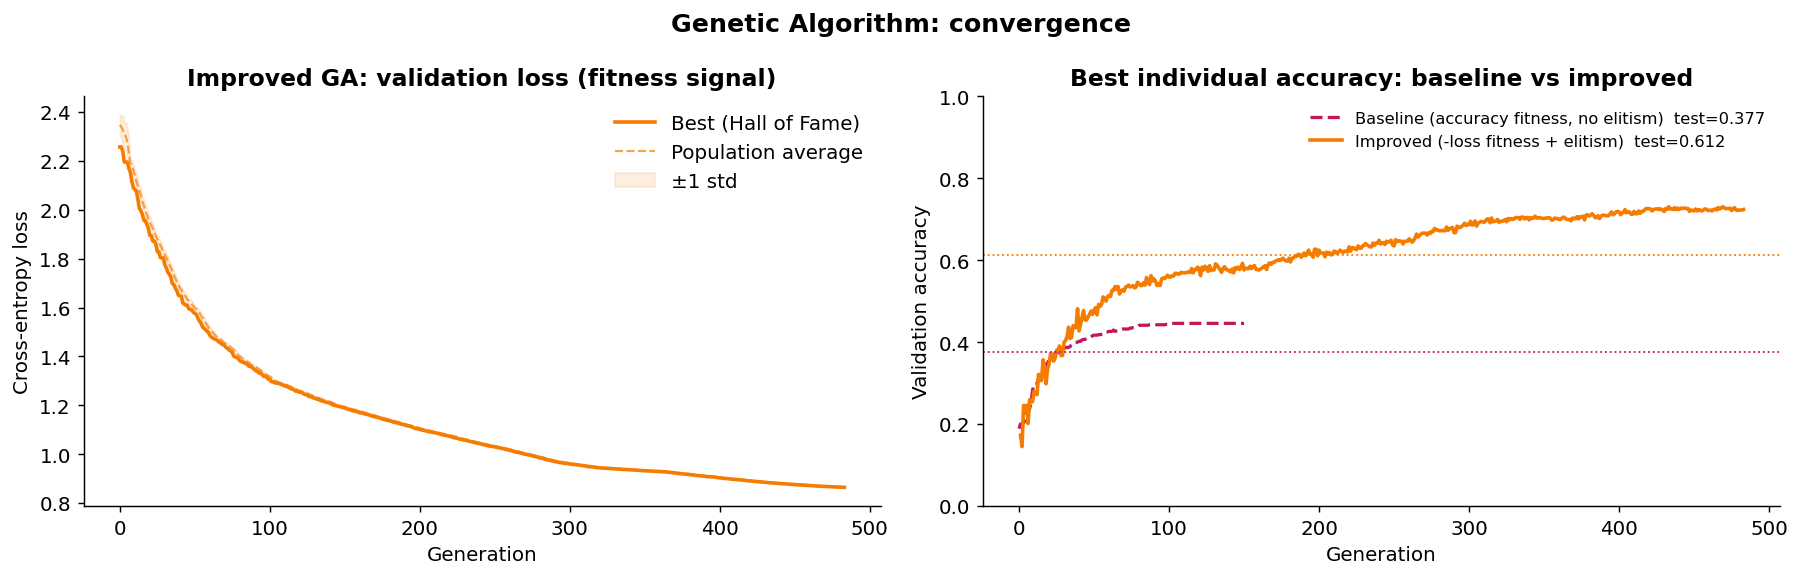

In [14]:
ga_best_loss = -np.array(logbook.select('max'))
ga_avg_loss  = -np.array(logbook.select('avg'))
ga_std_loss  =  np.array(logbook.select('std'))
gens         = range(len(ga_best_loss))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(gens, ga_best_loss, color=GA, linewidth=2,   label='Best (Hall of Fame)')
axes[0].plot(gens, ga_avg_loss,  color=GA, linewidth=1.2, label='Population average', linestyle='--', alpha=0.7)
axes[0].fill_between(gens, ga_avg_loss - ga_std_loss, ga_avg_loss + ga_std_loss,
                     color=GA, alpha=0.12, label='±1 std')
axes[0].set_title('Improved GA: validation loss (fitness signal)')
axes[0].set_xlabel('Generation')
axes[0].set_ylabel('Cross-entropy loss')
axes[0].legend(frameon=False)

axes[1].plot(ga_best_acc_orig, color=PINK, linewidth=1.8,
             label=f'Baseline (accuracy fitness, no elitism)  test={ga_test_acc_orig:.3f}',
             linestyle='--')
axes[1].plot(range(1, len(ga_best_acc)+1), ga_best_acc, color=GA, linewidth=2,
             label=f'Improved (-loss fitness + elitism)  test={ga_test_acc:.3f}')
axes[1].axhline(ga_test_acc_orig, color=PINK, linestyle=':', linewidth=1)
axes[1].axhline(ga_test_acc,      color=GA,   linestyle=':', linewidth=1)
axes[1].set_title('Best individual accuracy: baseline vs improved')
axes[1].set_xlabel('Generation')
axes[1].set_ylabel('Validation accuracy')
axes[1].set_ylim(0, 1)
axes[1].legend(frameon=False, fontsize=9)

plt.suptitle('Genetic Algorithm: convergence', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/ga_convergence.png', **SAVE)
plt.show()

---
## 6 · Comparison

Four views of the same question: which method is better, and in what sense?

### Summary  -  accuracy and time

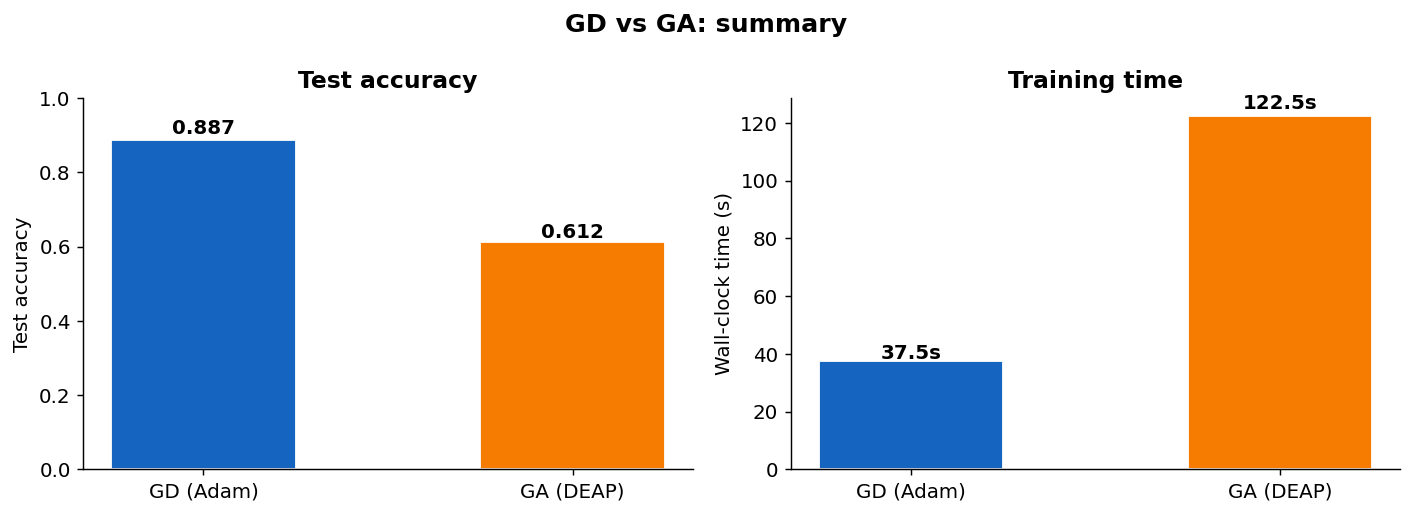

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, vals, ylabel, title in [
    (axes[0], [gd_test_acc, ga_test_acc], 'Test accuracy',      'Test accuracy'),
    (axes[1], [gd_time,     ga_time],     'Wall-clock time (s)', 'Training time'),
]:
    bars = ax.bar(['GD (Adam)', 'GA (DEAP)'], vals, color=[GD, GA], width=0.5, edgecolor='white')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if title == 'Test accuracy':
        ax.set_ylim(0, 1)
    for bar, v in zip(bars, vals):
        label = f'{v:.3f}' if title == 'Test accuracy' else f'{v:.1f}s'
        ax.text(bar.get_x() + bar.get_width()/2, v * 1.02, label,
                ha='center', fontweight='bold')

plt.suptitle('GD vs GA: summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/comparison_summary.png', **SAVE)
plt.show()

### Convergence
Two separate panels with independent x-axes so the natural scale of each method is preserved.
GD converges in 150 epochs; GA runs until early stopping (patience 50 generations).
The pink dashed line on the right panel is the GD test accuracy as a reference.

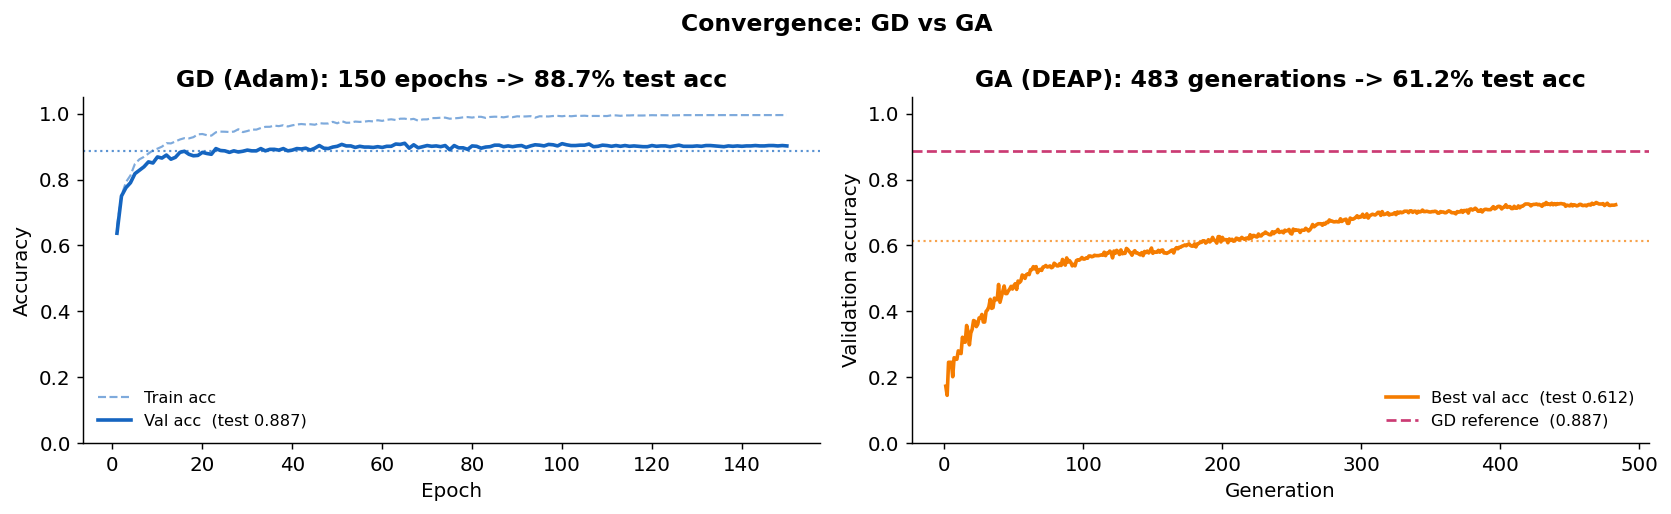

In [16]:
gens = range(1, len(ga_best_acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: GD convergence on its own epoch axis
epochs_range = range(1, EPOCHS + 1)
axes[0].plot(epochs_range, gd_train_acc, color=GD, linewidth=1.2,
             linestyle='--', alpha=0.55, label='Train acc')
axes[0].plot(epochs_range, gd_val_acc,   color=GD, linewidth=2,
             label=f'Val acc  (test {gd_test_acc:.3f})')
axes[0].axhline(gd_test_acc, color=GD, linestyle=':', linewidth=1.2, alpha=0.7)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title(f'GD (Adam): 150 epochs -> {gd_test_acc:.1%} test acc')
axes[0].set_ylim(0, 1.05)
axes[0].legend(frameon=False, fontsize=9)

# Right: GA convergence on its own generation axis
axes[1].plot(gens, ga_best_acc, color=GA, linewidth=2,
             label=f'Best val acc  (test {ga_test_acc:.3f})')
axes[1].axhline(ga_test_acc,  color=GA,   linestyle=':', linewidth=1.2, alpha=0.7)
axes[1].axhline(gd_test_acc,  color=PINK, linestyle='--', linewidth=1.5,
                label=f'GD reference  ({gd_test_acc:.3f})', alpha=0.85)
axes[1].set_xlabel('Generation')
axes[1].set_ylabel('Validation accuracy')
axes[1].set_title(f'GA (DEAP): {len(ga_best_acc)} generations -> {ga_test_acc:.1%} test acc')
axes[1].set_ylim(0, 1.05)
axes[1].legend(frameon=False, fontsize=9)

plt.suptitle('Convergence: GD vs GA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/comparison_convergence.png', **SAVE)
plt.show()


### Confusion matrices
Each row = true class · each column = predicted class · values normalised per row (recall).  
A perfect model has 1.0 on the diagonal. Off-diagonal entries show which classes get confused  -  usually acoustically similar pairs.

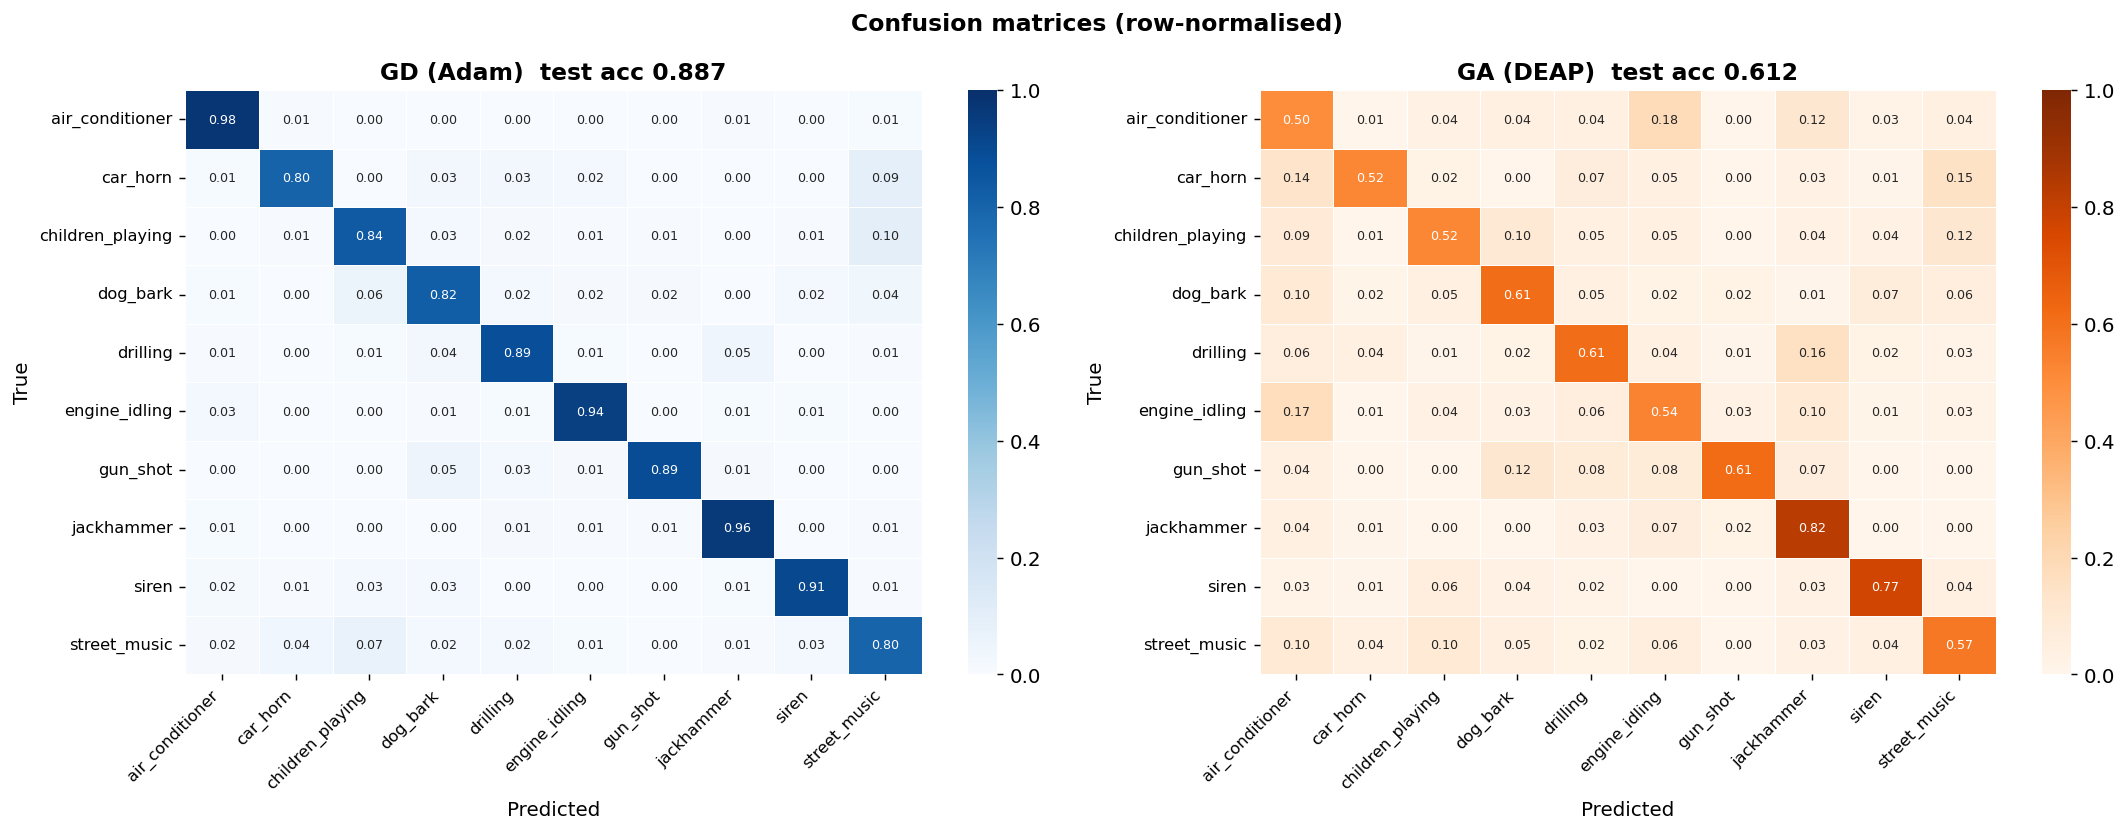

In [17]:
gd_model.eval()
ga_model.eval()
with torch.no_grad():
    gd_preds = gd_model(X_test_t).argmax(dim=1).numpy()
    ga_preds = ga_model(X_test_t).argmax(dim=1).numpy()
y_test_np = y_test_t.numpy()

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
for ax, preds, title, cmap in zip(
    axes,
    [gd_preds, ga_preds],
    [f'GD (Adam)  test acc {gd_test_acc:.3f}', f'GA (DEAP)  test acc {ga_test_acc:.3f}'],
    ['Blues', 'Oranges'],
):
    cm = confusion_matrix(y_test_np, preds, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap=cmap, ax=ax, linewidths=0.3,
                xticklabels=class_names, yticklabels=class_names,
                vmin=0, vmax=1, annot_kws={'size': 7})
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.suptitle('Confusion matrices (row-normalised)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/comparison_confusion.png', **SAVE)
plt.show()

### Per-class F1 score
F1 = harmonic mean of precision and recall  -  robust to class imbalance.  
Low F1 means the model either misses many samples of that class (low recall)  
or often predicts it incorrectly (low precision). Dashed lines show the macro average.

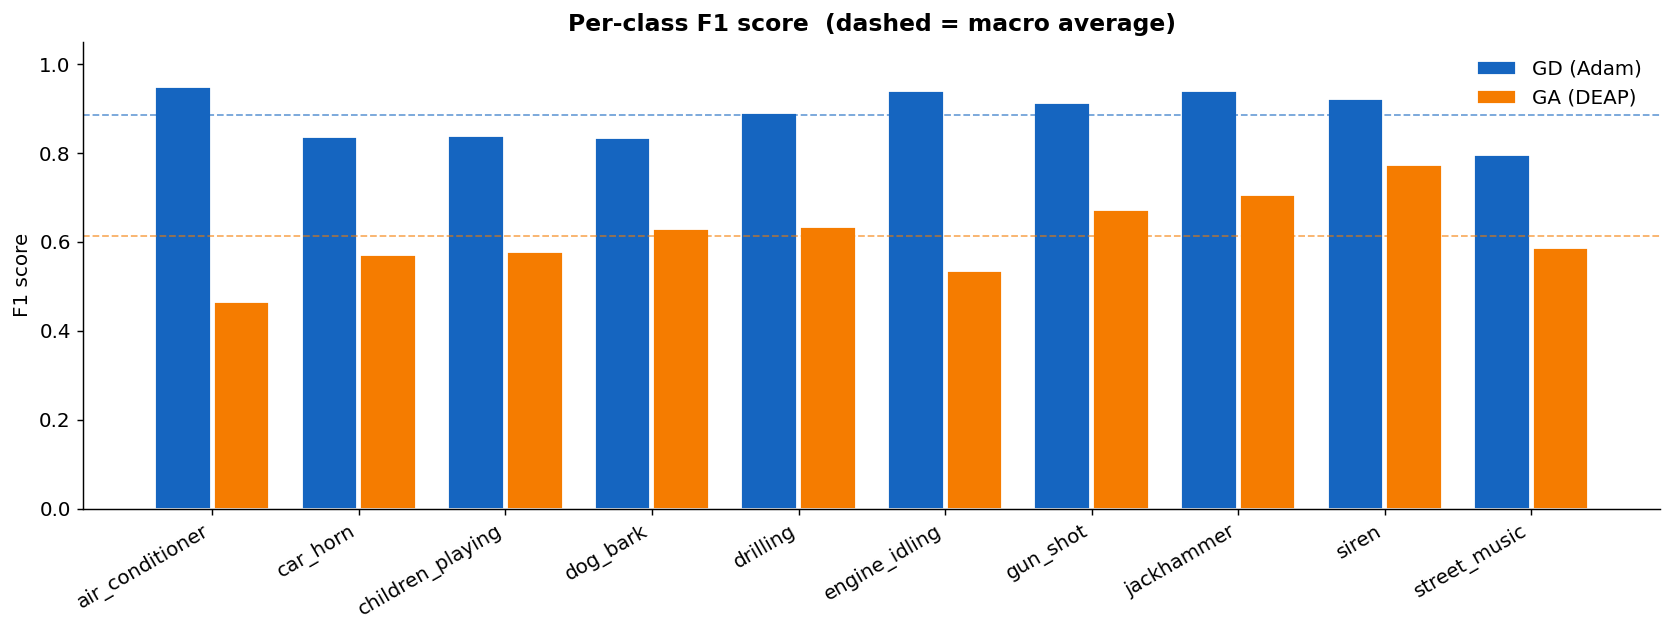

Macro F1  -  GD: 0.8852   GA: 0.6140


In [18]:
gd_f1 = f1_score(y_test_np, gd_preds, average=None)
ga_f1 = f1_score(y_test_np, ga_preds, average=None)

x = np.arange(len(class_names))
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - 0.2, gd_f1, 0.38, label='GD (Adam)', color=GD, edgecolor='white')
ax.bar(x + 0.2, ga_f1, 0.38, label='GA (DEAP)', color=GA, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=30, ha='right')
ax.set_ylabel('F1 score')
ax.set_ylim(0, 1.05)
ax.axhline(np.mean(gd_f1), color=GD, linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(np.mean(ga_f1), color=GA, linestyle='--', linewidth=1, alpha=0.6)
ax.set_title('Per-class F1 score  (dashed = macro average)')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('results/figures/comparison_f1.png', **SAVE)
plt.show()

print(f'Macro F1  -  GD: {np.mean(gd_f1):.4f}   GA: {np.mean(ga_f1):.4f}')